In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay,
    make_scorer
)
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV

In [2]:
df_raw = pd.read_excel("1 - Project Data.xlsx")

In [138]:
print(len(cols_all))
print(len(cols_drop))
print(len(cols_keep))
print(len(cols_cat))
print(len(cols_num))
print(len(target))

31
11
20
16
3
1


In [140]:
df.columns

Index(['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value',
       'Gender_Male', 'Senior Citizen_Yes', 'Partner_Yes', 'Dependents_Yes',
       'Phone Service_Yes', 'Paperless Billing_Yes',
       'Multiple Lines_No phone service', 'Multiple Lines_Yes',
       'Internet Service_Fiber optic', 'Internet Service_No',
       'Online Security_No internet service', 'Online Security_Yes',
       'Online Backup_No internet service', 'Online Backup_Yes',
       'Device Protection_No internet service', 'Device Protection_Yes',
       'Tech Support_No internet service', 'Tech Support_Yes',
       'Streaming TV_No internet service', 'Streaming TV_Yes',
       'Streaming Movies_No internet service', 'Streaming Movies_Yes',
       'Contract_One year', 'Contract_Two year',
       'Payment Method_Credit card (automatic)',
       'Payment Method_Electronic check', 'Payment Method_Mailed check'],
      dtype='str')

In [7]:
cols_all = ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
           'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
           'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
           'Multiple Lines', 'Internet Service', 'Online Security',
           'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
           'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
           'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
           'Churn Reason']


cols_drop = ['CustomerID', 'Count', 'Country', 'State', 'City', 'Lat Long',
             'Latitude', 'Longitude', 'Churn Label', 'Churn Reason', 'Zip Code']

cols_keep = ['Phone Service', 'Internet Service', 'Total Charges', 'Paperless Billing', 
             'Partner', 'Online Backup', 'Multiple Lines', 'Monthly Charges', 'Churn Value',
             'Contract', 'Tech Support', 'Online Security', 'Device Protection',
             'Dependents', 'Senior Citizen', 'Gender', 'Streaming TV', 
             'Payment Method', 'Streaming Movies', 'Tenure Months']


target = ["Churn Value"]

cols_cat = ['Gender','Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 
            'Paperless Billing', 'Multiple Lines', 'Internet Service', 
            'Online Security', 'Online Backup', 'Device Protection',
            'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract',
            'Payment Method']

cols_num = ['Monthly Charges', 'Total Charges', 'Tenure Months']


cols_new = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value',
       'Gender_Male', 'Senior Citizen_Yes', 'Partner_Yes', 'Dependents_Yes',
       'Phone Service_Yes', 'Paperless Billing_Yes',
       'Multiple Lines_No phone service', 'Multiple Lines_Yes',
       'Internet Service_Fiber optic', 'Internet Service_No',
       'Online Security_No internet service', 'Online Security_Yes',
       'Online Backup_No internet service', 'Online Backup_Yes',
       'Device Protection_No internet service', 'Device Protection_Yes',
       'Tech Support_No internet service', 'Tech Support_Yes',
       'Streaming TV_No internet service', 'Streaming TV_Yes',
       'Streaming Movies_No internet service', 'Streaming Movies_Yes',
       'Contract_One year', 'Contract_Two year',
       'Payment Method_Credit card (automatic)',
       'Payment Method_Electronic check', 'Payment Method_Mailed check']

In [7]:
df = preprocess(df_raw,cols_drop,cols_cat,cols_num)

# Factor Influence on Churn

In [102]:
def churn_rate_by(col):
    g = df.groupby(col)["Churn Value"].agg(["sum","count"])
    g.columns = ["churned","total"]
    g["rate"] = g["churned"] / g["total"] * 100
    churn_factor = g["rate"][0]/g["rate"][1]
    return g.reset_index(), churn_factor

In [105]:
churn_rate_by("Dependents_Yes")

,Dependents_Yes,churned,total,rate
0,0,1763,5416,32.551699
1,1,106,1627,6.515058


In [113]:
corr = df.corr()

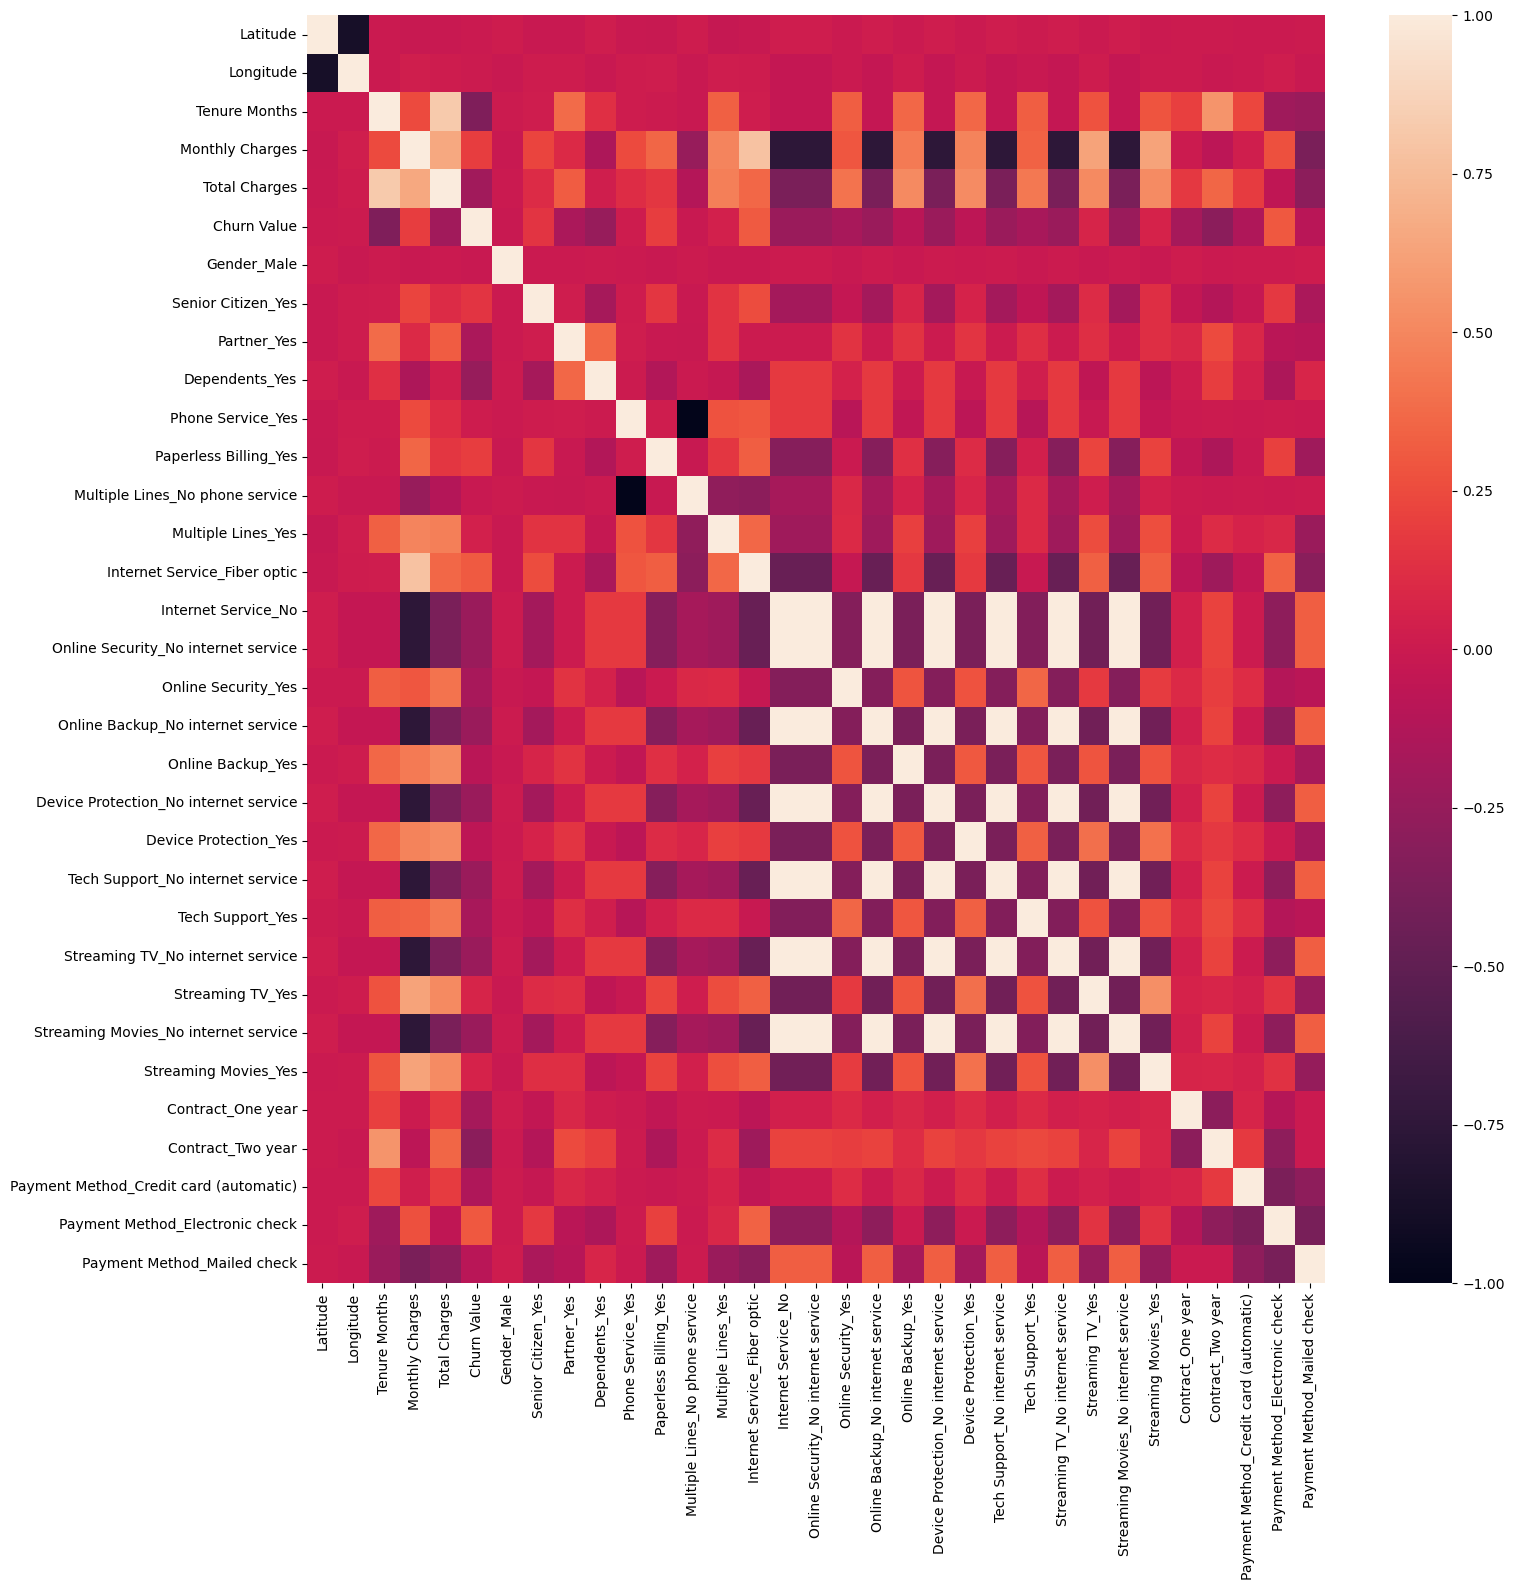

In [117]:
plt.figure(figsize=(16, 16))
sns.heatmap(corr)
# plt.xticks(rotation=45, ha="right")
plt.tight_layout()

# LogReg

In [4]:
df_raw = pd.read_excel("1 - Project Data.xlsx")

In [5]:
def clean(df, cols_drop, cols_cat, cols_num):

    # Make a copy 
    df = df.copy()
    
    # Drop columns we don't need
    df = df.drop(cols_drop, axis=1)

    # Convert Total Charges to numeric
    df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

    # Replace NaN with 0
    df = df.fillna(0)

    # One-hot encode categorical columns
    for col in cols_cat:
        dummies = pd.get_dummies(
            df[col],
            prefix=col,
            drop_first=True,
            dtype=int
        )
        df = pd.concat([df.drop(columns=col), dummies], axis=1)
        
    return df

In [8]:
df = clean(df_raw,cols_drop,cols_cat,cols_num)

In [9]:
target = 'Churn Value'
X = df.drop(columns = target)
y = df[target]

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

`precision_at_k_fraction`: The main goal of our model is to predict the top 500 most likely to churn customers out of the 5174 remaining customers. We can evaluate our models performance on this task on any subset of the dataset as follows. 

Take a subset of the dataset (validation/test set) of size $n$. We want the top $\frac{500}{5174} = 0.097 = k$ most likely. We rank our subset based on predicted probability of churning and examine the top $n*k$ customers. We then calculate how many of those customers actually churned and that is our precision at k-fraction.

In [33]:
TOP_K_FRACTION = 500 / 5174  # ~0.097

def precision_at_k_fraction(y_true, y_proba, k_fraction=TOP_K_FRACTION):
    y_true = np.asarray(y_true)
    n_top = max(1, int(round(len(y_true) * k_fraction)))
    top_idx = np.argsort(y_proba)[::-1][:n_top]
    return y_true[top_idx].mean()

precision_at_k_scorer = make_scorer(
    precision_at_k_fraction, response_method="predict_proba", greater_is_better=True
)

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), cols_num),
    ]
)

pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("clf", LogisticRegression(max_iter=2000, random_state=42)),
    ]
)

param_grid = {
    "clf__C": [0.1,1, 10, 100],
    "clf__penalty": ["l1", "l2"],
    "clf__solver": ["liblinear"],
    "clf__class_weight": [None, "balanced"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "precision_at_k": precision_at_k_scorer,
    "average_precision": "average_precision",
    "f1": "f1",
}

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring=scoring,
    refit="roc_auc",   # picks the best model by roc_auc, refits it on all of X_train
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    verbose=1,
)

In [12]:
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print(f"Best CV ROC AUC: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params: {'clf__C': 10, 'clf__class_weight': None, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
Best CV ROC AUC: 0.8072


In [13]:
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results_sorted = cv_results.sort_values("mean_test_roc_auc", ascending=False)
print(
    cv_results_sorted[
        ["params", "mean_test_roc_auc", "std_test_roc_auc","mean_test_precision_at_k"
         , "mean_test_average_precision", "mean_test_f1"]
    ].head(10).to_string(index=False)
)

                                                                                            params  mean_test_roc_auc  std_test_roc_auc  mean_test_precision_at_k  mean_test_average_precision  mean_test_f1
       {'clf__C': 10, 'clf__class_weight': None, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}           0.807238          0.014747                      0.76                     0.604639      0.527558
      {'clf__C': 100, 'clf__class_weight': None, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}           0.807237          0.014744                      0.76                     0.604671      0.527359
      {'clf__C': 100, 'clf__class_weight': None, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}           0.807234          0.014740                      0.76                     0.604646      0.527558
       {'clf__C': 10, 'clf__class_weight': None, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}           0.807230          0.014754                      0.76                   

In [16]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("\nTest set performance:")
print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print(precision_at_k_fraction(y_test, y_pred))


Test set performance:
ROC AUC: 0.8106
Confusion matrix:
[[932 103]
 [217 157]]
0.63


In [17]:
best_logreg = LogisticRegression(penalty = 'l1', class_weight='balanced', C = 1)
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]
print("\nTest set performance:")
print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print(precision_at_k_fraction(y_test, y_pred))


Test set performance:
ROC AUC: 0.8106
Confusion matrix:
[[932 103]
 [217 157]]
0.63


# GB Decision Forest

In [21]:
# Build the pipeline with HistGradientBoostingClassifier
pipe = Pipeline(
    steps=[
        ("clf", HistGradientBoostingClassifier(random_state=42)),
    ]
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "precision_at_k": precision_at_k_scorer,
    "average_precision": "average_precision",
    "f1": "f1",
}

In [19]:
param_grid = {
    "clf__learning_rate": [0.01, 0.05, 0.1],
    "clf__max_iter": [100, 200],              # Number of trees (boosting iterations)
    "clf__max_depth": [3, 5, None],           # Tree depth
    "clf__min_samples_leaf": [20, 50],
    "clf__class_weight": [None, "balanced"],
}

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring=scoring,
    refit="roc_auc",   # picks the best model by roc_auc, refits it on all of X_train
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    verbose=1,
)

In [ ]:
grid_search.fit(X_train, y_train)

# Print best parameters and best CV score
print(f"Best ROC-AUC score: {grid_search.best_score_:.4f}")
print("Best parameters found:")
print(grid_search.best_params_)

In [25]:
# Define a search space instead of exact grids
param_distributions = {
    "clf__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "clf__max_iter": [100, 200, 300],
    "clf__max_depth": [3, 5, 7, 10],
    "clf__min_samples_leaf": [10, 20, 50, 100],
    "clf__class_weight": [None, "balanced"],
}

random_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distributions,
    n_iter=15,             # Limit to 15 random combinations total!
    scoring=scoring,
    refit="roc_auc",
    cv=cv,
    n_jobs=-2,             # Use all CPU cores
    random_state=42,
    verbose=2,
)

In [26]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'clf__class_weight': [None, 'balanced'], 'clf__learning_rate': [0.01, 0.03, ...], 'clf__max_depth': [3, 5, ...], 'clf__max_iter': [100, 200, ...], ...}"
,n_iter,15
,scoring,"{'average_precision': 'average_precision', 'f1': 'f1', 'precision_at_k': make_scorer(p...redict_proba'), 'roc_auc': 'roc_auc'}"
,n_jobs,-2
,refit,'roc_auc'
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [30]:
cv_results = pd.DataFrame(random_search.cv_results_)
cv_results_sorted = cv_results.sort_values("mean_test_roc_auc", ascending=False)
print(
    cv_results_sorted[
        ["params", "mean_test_roc_auc", "std_test_roc_auc","mean_test_precision_at_k"
         , "mean_test_average_precision", "mean_test_f1"]
    ].head(10).to_string(index=False)
)

                                                                                                                                 params  mean_test_roc_auc  std_test_roc_auc  mean_test_precision_at_k  mean_test_average_precision  mean_test_f1
  {'clf__min_samples_leaf': 50, 'clf__max_iter': 300, 'clf__max_depth': 3, 'clf__learning_rate': 0.03, 'clf__class_weight': 'balanced'}           0.863551          0.010881                    0.8200                     0.687969      0.644721
        {'clf__min_samples_leaf': 20, 'clf__max_iter': 300, 'clf__max_depth': 3, 'clf__learning_rate': 0.01, 'clf__class_weight': None}           0.861252          0.012264                    0.8000                     0.675627      0.556309
        {'clf__min_samples_leaf': 50, 'clf__max_iter': 200, 'clf__max_depth': 7, 'clf__learning_rate': 0.01, 'clf__class_weight': None}           0.860493          0.010688                    0.8050                     0.679208      0.566389
        {'clf__min_samples_leaf'

In [27]:
# 2. Extract the Best Model
# -------------------------
# GridSearch automatically refits the best estimator on the ENTIRE X_train dataset
best_pipe = random_search.best_estimator_

In [35]:
# 3. Make Predictions on Test Data
# --------------------------------
# Get class predictions (0 or 1)
y_pred = best_pipe.predict(X_test)

# Get predicted probabilities (useful for ROC-AUC, precision-recall curves, etc.)
y_proba = best_pipe.predict_proba(X_test)[:, 1]

In [36]:
print("\n--- Test Set Results ---")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"Test Precision on top 7%: {precision_at_k_fraction(y_test,y_pred)}")


--- Test Set Results ---
Test ROC-AUC: 0.8523
Test Precision on top 7%: 0.64
